# Midterm Exam

## Grading Rubric

Each question is worth 20 points. The answer to each question will be graded in terms of:


* Correct Analysis & Computation `(8 points)`
  - Correct use of pandas operations (groupby, aggregation, filtering).
  - Accurate statistics or summaries.

* Appropriate Use of Visuals / Tables — `(6 points)`
  - Visualization or table is relevant to the question.
  - Plot type is appropriate (bar, boxplot, line, etc.).
  - Labels and axes are clear.


* Interpretation and Reasoning — `(6 points)`
  - Conclusions are clearly stated.
  - Interpretations are supported by data.
  - Reasoning is logical and coherent.

## Variable Definitions

* **hotel**
  - H1 = Resort Hotel
  - H2 = City Hotel

* **is_canceled** - Value indicating if the booking was canceled.
  - (1) canceled
  - (0) not canceled

* **lead_time** - Number of days that elapsed between the entering date of the booking into the PMS and the arrival date

* **arrival_date_year** - Year of arrival date

* **arrival_date_month** - Month of arrival date

* **arrival_date_week_number** - Week number of year for arrival date

* **arrival_date_day_of_month** - Day of arrival date

* **stays_in_weekend_nights** - Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel

* **stays_in_week_nights** - Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel

* **adults** - Number of adults

* **children** - Number of children

* **babies** - Number of babies

* **meal** - Type of meal booked. Categories are presented in standard hospitality meal packages:
  - Undefined/SC – no meal package.
  - BB – Bed & Breakfast.
  - HB – Half board (breakfast and one other meal – usually dinner).
  - FB – Full board (breakfast, lunch and dinner)

* **country** - Country of origin. Categories are represented in the ISO 3155–3:2013 format

* **market_segment** - Market segment designation. In categories, the term “TA” means “Travel Agents” and “TO” means “Tour Operators”

* **distribution_channel** - Booking distribution channel. The term “TA” means “Travel Agents” and “TO” means “Tour Operators”

* **is_repeated_guest** - Value indicating if the booking name was from a repeated guest.
  - 1 is a repeated guest.
  - 0 is not a repeated guest.

* **previous_cancellations** - Number of previous bookings that were cancelled by the customer prior to the current booking

* **previous_bookings_not_canceled** - Number of previous bookings not cancelled by the customer prior to the current booking

* **reserved_room_type** - Code of room type reserved. Code is presented instead of designation for anonymity reasons.

* **assigned_room_type** - Code for the type of room assigned to the booking. Sometimes the assigned room type differs from the reserved room type due to hotel operation reasons (e.g. overbooking) or by customer request. Code is presented instead of designation for anonymity reasons.

* **booking_changes** - Number of changes/amendments made to the booking from the moment the booking was entered on the PMS until the moment of check-in or cancellation

* **deposit_type** - Indication on if the customer made a deposit to guarantee the booking. This variable can assume three categories:

  - No Deposit – no deposit was made.
  - Non Refund – a deposit was made in the value of the total stay cost.  
  - Refundable – a deposit was made with a value under the total cost of stay.

* **agent** - ID of the travel agency that made the booking

* **company** - ID of the company/entity that made the booking or responsible for paying the booking. ID is presented instead of designation for anonymity reasons

* **days_in_waiting_list** - Number of days the booking was in the waiting list before it was confirmed to the customer

* **customer_type** - Type of booking, assuming one of four categories:   

  - Contract - when the booking has an allotment or other type of contract associated to it.
  - Group – when the booking is associated to a group.
  - Transient – when the booking is not part of a group or contract, and is not associated to other transient booking.
  - Transient-party – when the booking is transient, but is associated to at least other transient booking

* **adr** - Average Daily Rate as defined by dividing the sum of all lodging transactions by the total number of staying nights

* **required_car_parking_spaces** - Number of car parking spaces required by the customer

* **total_of_special_requests** - Number of special requests made by the customer (e.g. twin bed or high floor)

* **reservation_status** - Reservation last status, assuming one of three categories:
  - Canceled – booking was canceled by the customer.
  - Check-Out – customer has checked in but already departed.
  - No-Show – customer did not check-in and did inform the hotel of the reason why

* **reservation_status_date** - Date at which the last status was set. This variable can be used in conjunction with the ReservationStatus to

In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")

print("Path to dataset files:", path)

100%|██████████| 1.25M/1.25M [00:08<00:00, 155kB/s]

Extracting files...
Path to dataset files: /home/rbo/.cache/kagglehub/datasets/jessemostipak/hotel-booking-demand/versions/1


In [21]:
import os
import pandas as pd
import shutil
import matplotlib.pyplot as plt

In [22]:
contents = os.listdir(path)

# Select file
filename = contents[0]
source_file = os.path.join(path, filename)

# Use current notebook folder
notebook_folder = os.getcwd()               # this is where the .ipynb file is
target_file = os.path.join(notebook_folder, filename)

# Copy into current folder
shutil.copy2(source_file, target_file)

print("Saved file to:", target_file)

Saved file to: /home/rbo/projects/python/CCDATSCL_EXAM_COM221/hotel_bookings.csv


In [23]:
df = pd.read_csv(target_file)

In [24]:
df.head(15)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.00,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.00,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.00,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.50,0,0,Canceled,2015-04-22


## 1. Dataset Overview & Core Distributions `(20 points)`

**Question:** What do the shapes and spread of the `lead_time` and `adr` distributions suggest about typical booking behavior and extreme cases in this dataset?

Perform an exploratory analysis of the distributional characteristics of key numerical variables in the hotel booking dataset.

You must:
- Analyze the distribution of lead_time and adr
- Use appropriate summary statistics and visualizations to support your analysis
- Identify any skewness and/or outliers in these variables

In [25]:
df[['lead_time', 'adr']].describe()

,lead_time,adr
count,119390.000000,119390.000000
mean,104.011416,101.831122
std,106.863097,50.535790
min,0.000000,-6.380000
25%,18.000000,69.290000
50%,69.000000,94.575000
75%,160.000000,126.000000
max,737.000000,5400.000000


In [26]:
df[['lead_time', 'adr']].skew()

lead_time     1.346550
adr          10.530214
dtype: float64

<Axes: ylabel='Frequency'>

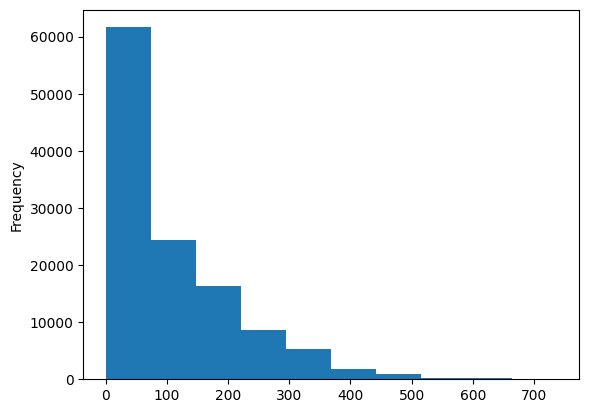

In [27]:
df['lead_time'].plot.hist()

<Axes: >

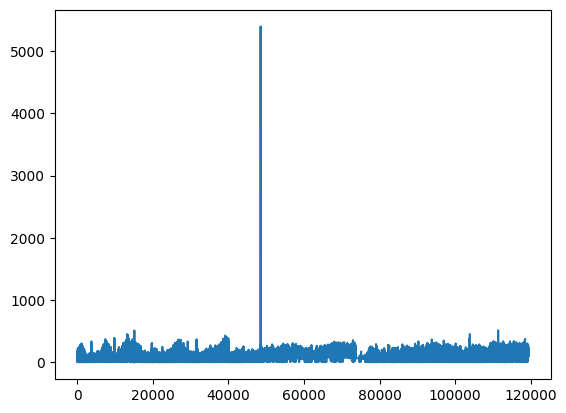

In [28]:
df['adr'].plot()

Based on the shapes and the spread of the lead_time and adr, it suggests that most of the bookings are done in the same day as checking in itself.

## 2. Booking Cancellations and Lead Time `(20 points)`

**Question**: Do bookings with longer lead times tend to cancel more often?

Analyze how `lead_time` differs between canceled and non-canceled bookings.

You must:
- Compute appropriate summary statistics
- Use at least one visualization
- Clearly describe the pattern you observe



In [29]:
# put your answer here
df.query('is_canceled == 1')[['lead_time','is_canceled']].mean()

lead_time      144.848815
is_canceled      1.000000
dtype: float64

In [30]:
# put your answer here
df.query('is_canceled == 0')[['lead_time','is_canceled']].mean()

lead_time      79.984687
is_canceled     0.000000
dtype: float64

In [31]:
print("Max: ", df['lead_time'].max())
print("Min: ", df['lead_time'].min())

Max:  737
Min:  0


In [32]:
df.groupby('is_canceled')['lead_time'].mean()

is_canceled
0     79.984687
1    144.848815
Name: lead_time, dtype: float64

/tmp/ipykernel_5065/2562953490.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[df['is_canceled'] == 0]['lead_time'], df[df['is_canceled'] == 1]['lead_time']], labels=['Not Canceled', 'Canceled'])


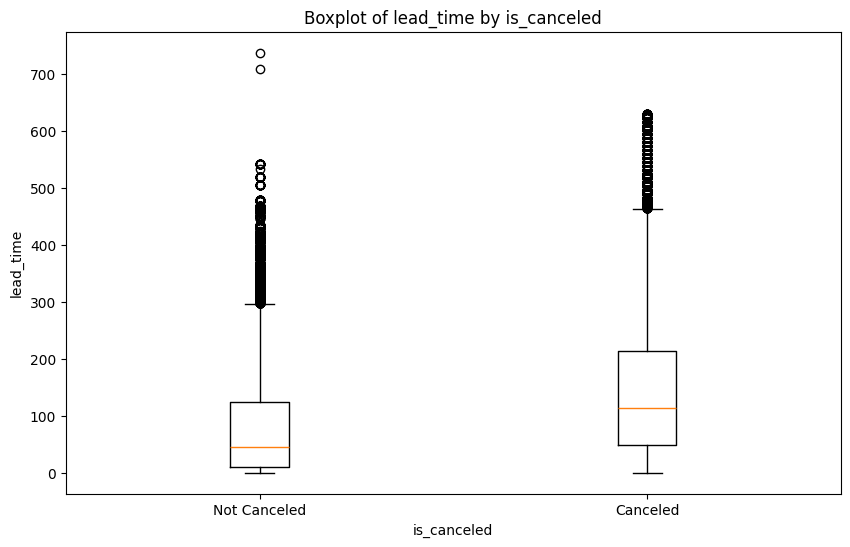

In [36]:
plt.figure(figsize=(10, 6))
plt.boxplot([df[df['is_canceled'] == 0]['lead_time'], df[df['is_canceled'] == 1]['lead_time']], labels=['Not Canceled', 'Canceled'])    
plt.ylabel("lead_time")
plt.xlabel("is_canceled")
plt.title("Boxplot of lead_time by is_canceled")
plt.show()

Based on the data, it is observed that there are more canceled bookings than not canceled bookings when the lead time is longer.

## 3. Seasonality and Pricing `(20 points)`

**Question**: Do `Resort Hotels` and `City Hotels` exhibit different seasonal pricing behaviors throughout the year? If so, during which months are these differences most pronounced?

Analyze how Average Daily Rate (ADR) varies across arrival months, and compare this pattern between Resort Hotels and City Hotels.

You must:
- Aggregate ADR by month and hotel type
- Use a visualization to support your analysis
- Identify at least one seasonal pricing pattern

In [39]:
monthly_adr = (
    df.groupby(['hotel', 'arrival_date_month'])['adr']
      .mean()
      .reset_index()
)

In [40]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]
monthly_adr['arrival_date_month'] = pd.Categorical(
    monthly_adr['arrival_date_month'],
    categories=month_order,
    ordered=True
)

In [41]:
# Pivot for plotting
pivot_adr = monthly_adr.pivot(
    index='arrival_date_month',
    columns='hotel',
    values='adr'
)

<Figure size 1000x600 with 0 Axes>

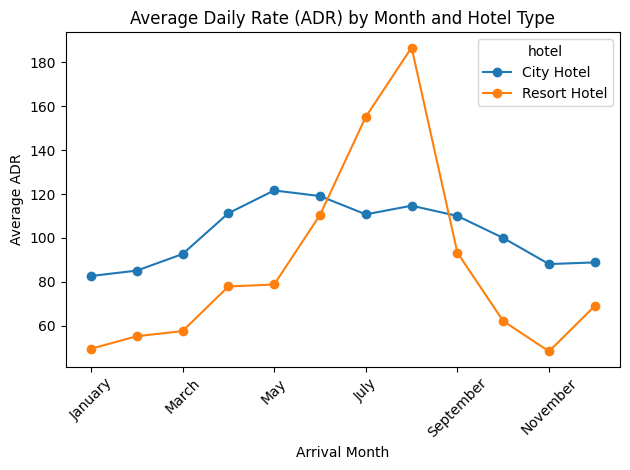

In [42]:
# Visualization
plt.figure(figsize=(10,6))
pivot_adr.plot(kind='line', marker='o')
plt.title('Average Daily Rate (ADR) by Month and Hotel Type')
plt.xlabel('Arrival Month')
plt.ylabel('Average ADR')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the graph above, where both hotels have spiked in April to August while the other months. However, Resort Hotel exhibit huge spikes in comparison to City Hotel where it has a small bump in the mentioned months.

## 4. Customer Behavior `(20 points)`

**Question:** Do repeated guests behave differently from first-time guests?

Compare repeated guests and non-repeated guests in terms of:
- Cancellation rate
- Booking behavior (e.g., booking changes or lead time)
- Use summary statistics and/or visualizations to support your answer.


In [43]:
# Split groups
repeated = df[df['is_repeated_guest'] == 1]
first_time = df[df['is_repeated_guest'] == 0]

In [44]:
# Cancellation rate comparison
cancellation_rates = df.groupby('is_repeated_guest')['is_canceled'].mean()
print("Cancellation rates:\n", cancellation_rates)

Cancellation rates:
 is_repeated_guest
0    0.377851
1    0.144882
Name: is_canceled, dtype: float64


In [45]:
# Booking behavior: lead time & booking changes summary
summary_stats = df.groupby('is_repeated_guest')[['lead_time', 'booking_changes']].describe()
print("\nBooking behavior summary statistics:\n", summary_stats)


Booking behavior summary statistics:
                   lead_time                                                  \
                      count        mean         std  min   25%   50%    75%   
is_repeated_guest                                                             
0                  115580.0  106.425221  106.939139  0.0  21.0  72.0  163.0   
1                    3810.0   30.786352   73.411688  0.0   0.0   3.0   14.0   

                         booking_changes                                     \
                     max           count      mean       std  min  25%  50%   
is_repeated_guest                                                             
0                  737.0        115580.0  0.219692  0.652030  0.0  0.0  0.0   
1                  361.0          3810.0  0.264567  0.659227  0.0  0.0  0.0   

                              
                   75%   max  
is_repeated_guest             
0                  0.0  21.0  
1                  0.0  10.0  


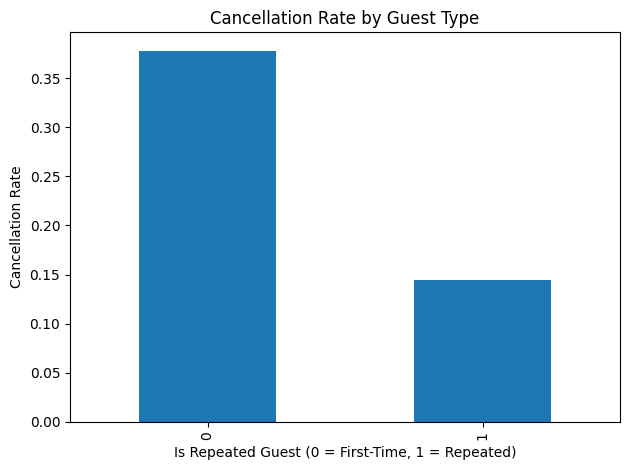

In [46]:
# Visualization: cancellation rate bar plot
plt.figure()
cancellation_rates.plot(kind='bar')
plt.title('Cancellation Rate by Guest Type')
plt.xlabel('Is Repeated Guest (0 = First-Time, 1 = Repeated)')
plt.ylabel('Cancellation Rate')
plt.tight_layout()
plt.show()

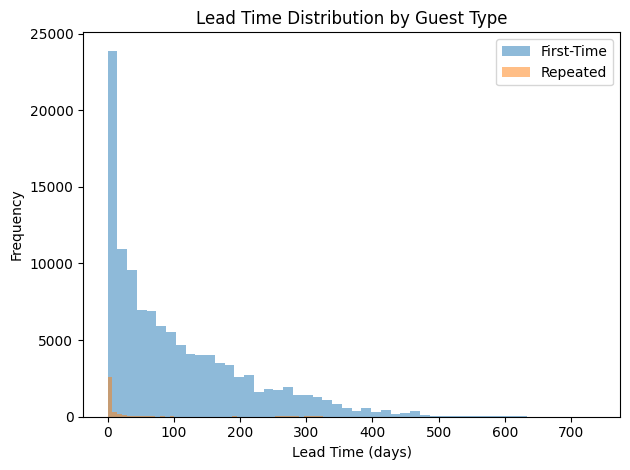

In [47]:
# Visualization: lead time distribution comparison
plt.figure()
first_time['lead_time'].plot(kind='hist', bins=50, alpha=0.5, label='First-Time')
repeated['lead_time'].plot(kind='hist', bins=50, alpha=0.5, label='Repeated')
plt.title('Lead Time Distribution by Guest Type')
plt.xlabel('Lead Time (days)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

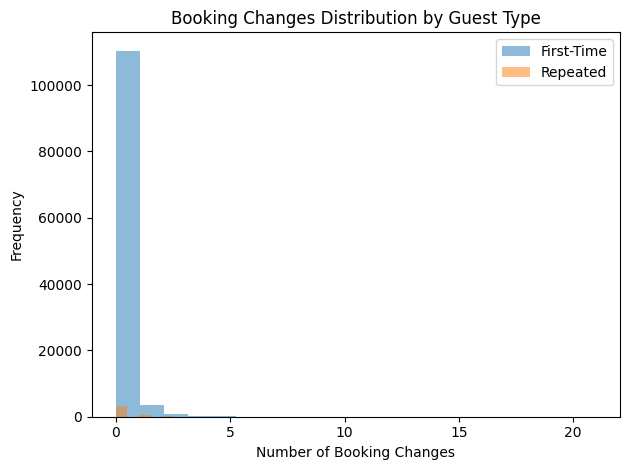

In [48]:
# Visualization: booking changes comparison
plt.figure()
first_time['booking_changes'].plot(kind='hist', bins=20, alpha=0.5, label='First-Time')
repeated['booking_changes'].plot(kind='hist', bins=20, alpha=0.5, label='Repeated')
plt.title('Booking Changes Distribution by Guest Type')
plt.xlabel('Number of Booking Changes')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

Based on the data gathered, repeated guests tend to have fewer booking changes and shorter lead time than one-time guests from both city hotels and resort hotels. They also have lower cancelation rate than non-repeated guests from both hotels.

## 5. Booking Cancellation Insights `(20 points)`

**Question:** Which combination of variables appears to have the strongest relationship with booking cancellations, and how do these variables interact to influence the likelihood of a cancellation?


Using at least three variables from the dataset, identify one strong pattern related to booking cancellations.

Your answer must:
- Clearly state the pattern
- Explain how the variables interact
- Support the conclusion with data


In [50]:
pattern_df = (
    df.groupby(['hotel', 'deposit_type', pd.cut(df['lead_time'], bins=[0,30,90,180,365,1000])])['is_canceled']
      .mean()
      .reset_index()
      .rename(columns={'is_canceled':'cancellation_rate', 'lead_time':'lead_time_bin'})
)

print("Segment-level cancellation rates by hotel, deposit type, and lead_time grouping:")
print(pattern_df.sort_values('cancellation_rate', ascending=False).head(20))

Segment-level cancellation rates by hotel, deposit type, and lead_time grouping:
           hotel deposit_type lead_time_bin  cancellation_rate
12    City Hotel   Refundable     (90, 180]           1.000000
9     City Hotel   Non Refund   (365, 1000]           1.000000
26  Resort Hotel   Refundable      (30, 90]           1.000000
21  Resort Hotel   Non Refund      (30, 90]           1.000000
13    City Hotel   Refundable    (180, 365]           1.000000
24  Resort Hotel   Non Refund   (365, 1000]           1.000000
8     City Hotel   Non Refund    (180, 365]           0.999189
7     City Hotel   Non Refund     (90, 180]           0.998260
6     City Hotel   Non Refund      (30, 90]           0.997724
23  Resort Hotel   Non Refund    (180, 365]           0.994118
5     City Hotel   Non Refund       (0, 30]           0.985130
22  Resort Hotel   Non Refund     (90, 180]           0.938871
10    City Hotel   Refundable       (0, 30]           0.750000
20  Resort Hotel   Non Refund       (

/tmp/ipykernel_5065/525123676.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['hotel', 'deposit_type', pd.cut(df['lead_time'], bins=[0,30,90,180,365,1000])])['is_canceled']


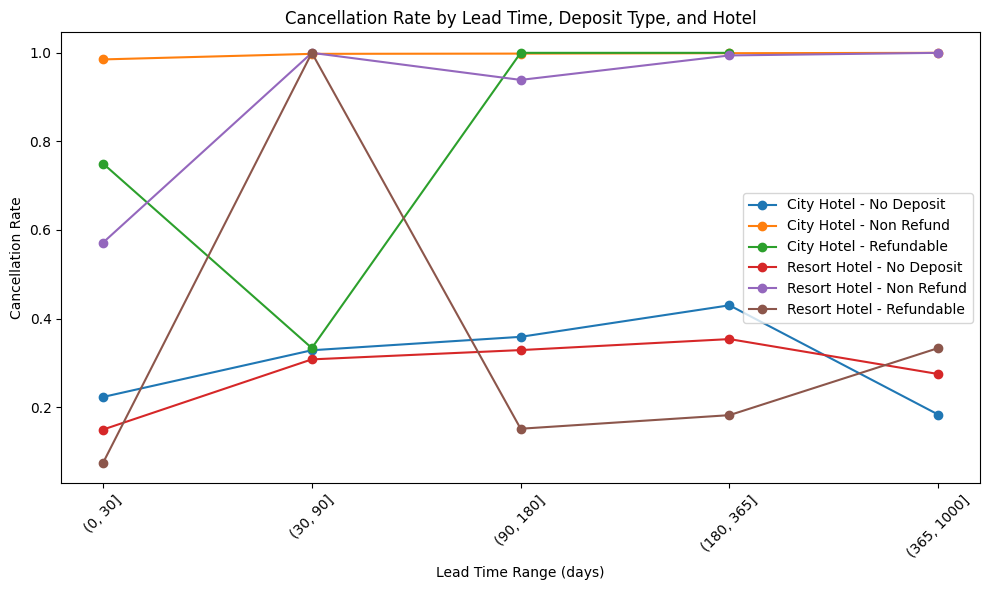

In [51]:
plt.figure(figsize=(10,6))
for h in pattern_df['hotel'].unique():
    subset = pattern_df[pattern_df['hotel'] == h]
    for dt in subset['deposit_type'].unique():
        subsub = subset[subset['deposit_type']==dt]
        plt.plot(subsub['lead_time_bin'].astype(str),
                 subsub['cancellation_rate'],
                 marker='o',
                 label=f"{h} - {dt}")

plt.title('Cancellation Rate by Lead Time, Deposit Type, and Hotel')
plt.xlabel('Lead Time Range (days)')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Based on the data gathered, nookings with long lead times, combined with non-refundable or no-deposit terms, show substantially higher cancellation rates. This interaction intensifies at Resort Hotels where long-horizon planning and flexible deposit policies lead to elevated cancel likelihood.

Other observations include
- Lead time increases uncertainty and future plan changes.
- Deposit type affects financial commitment and exposure.
- Hotel type moderates demand seasonality and guest behavior.
Together, these variables reveal a strong multivariate pattern linking booking flexibility and planning horizon to cancellation risk.